In [2]:
import pandas as pd
import sqlite3

df = pd.read_csv(
    "crunchbase_investments.csv",
    encoding="latin-1",
    engine="python"
)

In [3]:
conn = sqlite3.connect("crunchbase.db")

In [4]:
df.to_sql("investments", conn, if_exists="replace", index=False) #load csv into sqlite

52870

In [5]:
#group by company_category_code(top funding industries) and total funding
#query also excludes nulls from totals and notes missing count
query = """
SELECT 
    company_category_code AS industry,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN raised_amount_usd IS NOT NULL THEN raised_amount_usd ELSE 0 END) AS total_funding_usd,
    SUM(CASE WHEN raised_amount_usd IS NULL THEN 1 ELSE 0 END) AS missing_values
FROM investments
GROUP BY company_category_code
ORDER BY total_funding_usd DESC
LIMIT 10;
"""

In [6]:
result = pd.read_sql(query, conn)
print(result)

          industry  total_rows  total_funding_usd  missing_values
0          biotech        4951       1.103964e+11              91
1         software        7243       7.308452e+10             382
2           mobile        4067       6.477738e+10             414
3        cleantech        1948       5.270523e+10             103
4       enterprise        4489       4.586093e+10             278
5              web        5015       4.014326e+10             506
6          medical        1315       2.536711e+10              39
7      advertising        3200       2.507666e+10             195
8        ecommerce        2168       2.256722e+10             184
9  network_hosting        1075       2.241968e+10              63


In [7]:
df["funded_at"] = pd.to_datetime(df["funded_at"], errors="coerce") #parse dates and convert bad dates to NaT rather than crashing

In [8]:
#get quarter and year
df["year"] = df["funded_at"].dt.year
df["quarter"] = df["funded_at"].dt.to_period("Q")

In [9]:
trend = df.groupby("quarter").agg(
    deal_count=("funded_at", "count"),
    total_funding=("raised_amount_usd", "sum")
).reset_index()

In [10]:
yearly_trend = df.groupby("year").agg(
    deal_count=("funded_at", "count"),
    total_funding=("raised_amount_usd", "sum")
).reset_index()

In [11]:
df["raised_amount_usd"] = pd.to_numeric(df["raised_amount_usd"], errors="coerce")

In [12]:
#identify potential burst in funding; peak funding quarter
peak_quarter = trend.loc[trend["total_funding"].idxmax()]
print(peak_quarter)

quarter                 2008Q2
deal_count                1414
total_funding    35509497042.0
Name: 49, dtype: object


In [13]:
trend["quarter"] = trend["quarter"].dt.to_timestamp()

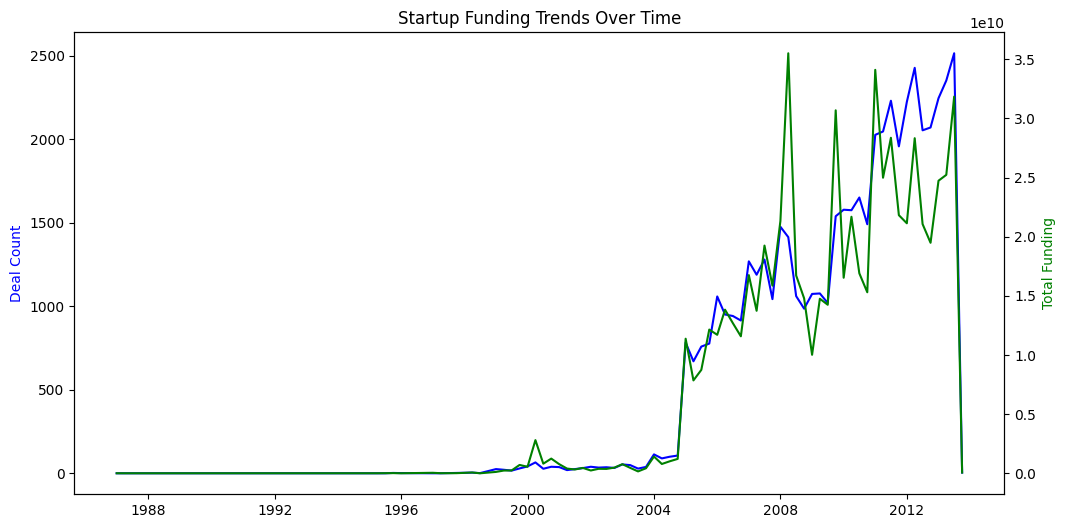

In [14]:
#visualize trend
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(trend["quarter"], trend["deal_count"], color="blue")
ax1.set_ylabel("Deal Count", color="blue")

ax2 = ax1.twinx()
ax2.plot(trend["quarter"], trend["total_funding"], color="green")
ax2.set_ylabel("Total Funding", color="green")

plt.title("Startup Funding Trends Over Time")
plt.xticks(rotation=45)
plt.show()

In [15]:
filtered = yearly_trend[
    (yearly_trend["year"] >= 2005) & 
    (yearly_trend["year"] <= 2013)
]

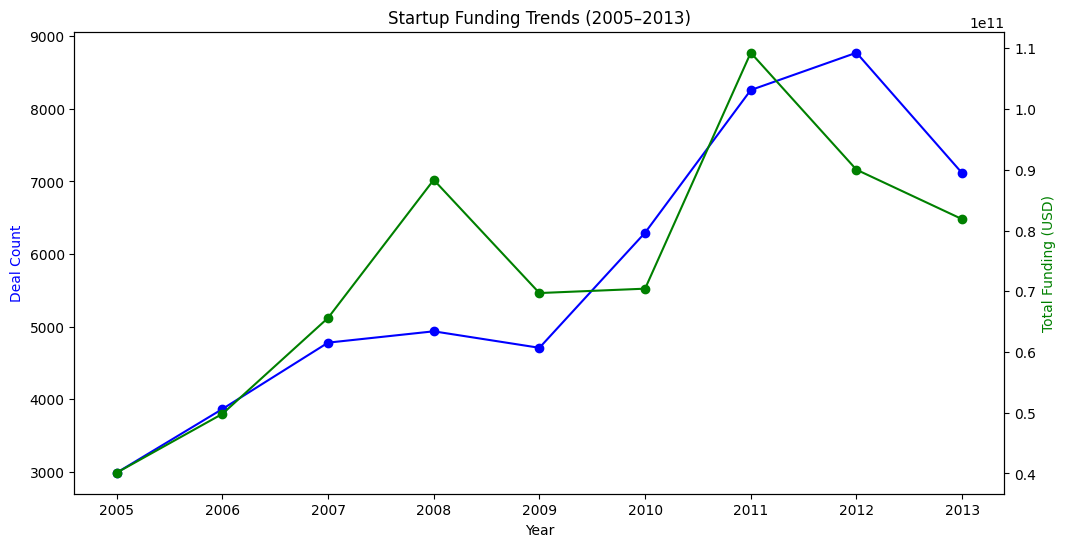

In [16]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(filtered["year"], filtered["deal_count"], color="blue", marker="o")
ax1.set_ylabel("Deal Count", color="blue")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(filtered["year"], filtered["total_funding"], color="green", marker="o")
ax2.set_ylabel("Total Funding (USD)", color="green")

plt.xticks(filtered["year"], rotation=45)

plt.title("Startup Funding Trends (2005–2013)")
plt.show()

In [17]:
#this query createss an investor-company base table and deduplicates rounds so we count unique companies and not funding rounds
#then we find each investors most common indusrty/sector they are interested in (shows their investment strategy focus)
#then find the big players by ranking based off capital deployed.
q2 = """
WITH investor_company AS (
    SELECT DISTINCT
        investor_name,
        company_name,
        company_category_code,
        raised_amount_usd
    FROM investments
    WHERE investor_name IS NOT NULL
),

investor_counts AS (
    SELECT
        investor_name,
        COUNT(DISTINCT company_name) AS portfolio_companies,
        SUM(raised_amount_usd) AS total_deployed
    FROM investor_company
    GROUP BY investor_name
),

sector_rank AS (
    SELECT
        investor_name,
        company_category_code,
        COUNT(*) AS sector_count,
        ROW_NUMBER() OVER (
            PARTITION BY investor_name
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM investor_company
    GROUP BY investor_name, company_category_code
),

top_sector AS (
    SELECT
        investor_name,
        company_category_code AS top_sector
    FROM sector_rank
    WHERE rn = 1
)

SELECT
    ic.investor_name,
    ic.portfolio_companies,
    ts.top_sector,
    ic.total_deployed
FROM investor_counts ic
JOIN top_sector ts
    ON ic.investor_name = ts.investor_name
WHERE ic.portfolio_companies >= 10
ORDER BY ic.total_deployed DESC;
"""

In [18]:
print(pd.read_sql(q2, conn))

                            investor_name  portfolio_companies  top_sector  \
0        Kleiner Perkins Caufield & Byers                  225     biotech   
1               New Enterprise Associates                  283    software   
2                           Goldman Sachs                   96    software   
3                          Accel Partners                  186    software   
4                         Sequoia Capital                  215  enterprise   
..                                    ...                  ...         ...   
794                                fbFund                   16         web   
795                     LaunchBox Digital                   12         web   
796  Entrepreneurs Roundtable Accelerator                   38         web   
797                          The Brandery                   11         web   
798                              AlphaLab                   20         web   

     total_deployed  
0      1.084093e+10  
1      9.336542e+09

In [19]:
q3 = """
WITH staged AS (
    SELECT
        company_name,

        CASE
            WHEN LOWER(funding_round_type) IN ('angel') THEN 'Seed/Angel'
            WHEN LOWER(funding_round_type) IN ('series-a') THEN 'Series A'
            WHEN LOWER(funding_round_type) IN ('series-b') THEN 'Series B'
            WHEN LOWER(funding_round_type) IN ('series-c+') THEN 'Series C+'
            ELSE NULL
        END AS stage

    FROM investments
    WHERE company_name IS NOT NULL
),

stage_counts AS (
    SELECT
        stage,
        COUNT(DISTINCT company_name) AS companies
    FROM staged
    WHERE stage IS NOT NULL
    GROUP BY stage
)

SELECT *
FROM stage_counts
ORDER BY
    CASE stage
        WHEN 'Seed/Angel' THEN 1
        WHEN 'Series A' THEN 2
        WHEN 'Series B' THEN 3
        WHEN 'Series C+' THEN 4
    END;
"""

In [20]:
df = pd.read_sql(q3, conn)
seed_total = df.loc[df["stage"] == "Seed/Angel", "companies"].values[0]
# calculate conversion %
df["conversion_rate"] = df["companies"] / seed_total * 100

# calculate drop-off %
df["drop_off"] = 100 - df["conversion_rate"]

print(df)

        stage  companies  conversion_rate   drop_off
0  Seed/Angel       2977       100.000000   0.000000
1    Series A       4590       154.182062 -54.182062
2    Series B       2855        95.901915   4.098085
3   Series C+       2072        69.600269  30.399731


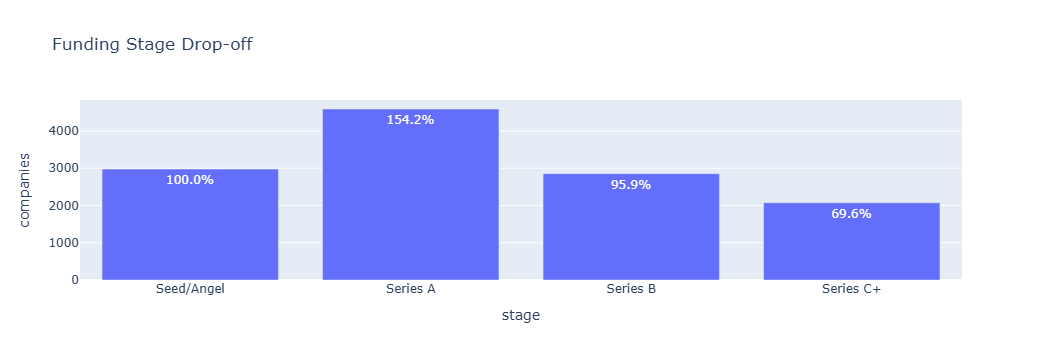

In [22]:
import plotly.express as px
fig = px.bar(
    df,
    x="stage",
    y="companies",
    text=df["conversion_rate"].round(1).astype(str) + "%",
    title="Funding Stage Drop-off"
)

fig.show()

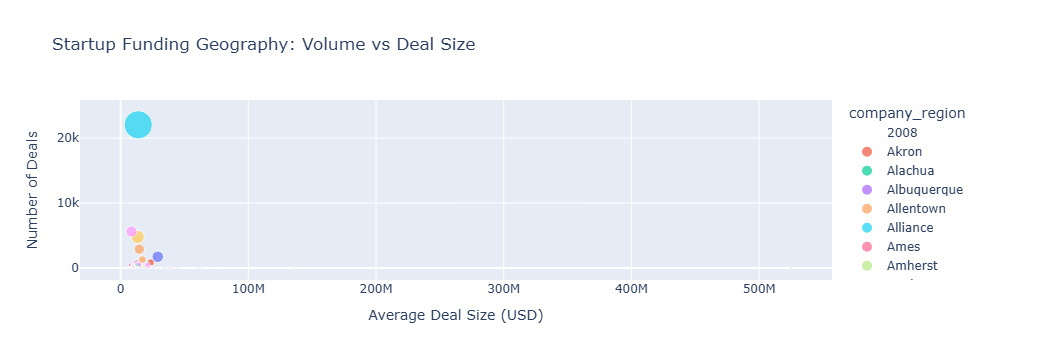

In [37]:
fig = px.scatter(
    region_df,
    x="avg_deal_size",
    y="deal_count",
    size="total_funding",
    color="company_region",
    hover_name="company_state_code",
    title="Startup Funding Geography: Volume vs Deal Size",
    labels={
        "avg_deal_size": "Average Deal Size (USD)",
        "deal_count": "Number of Deals"
    }
)

fig.show()